# 05c — Model C Training: Pre-Race Features (2018-2025)

Predicts **race-level finish_position** using 15 pre-race features.
CV: ExpandingWindowSplit (test season = 2025).

## 0. Setup

In [1]:
import os
from pathlib import Path

if not (Path.cwd() / "pyproject.toml").exists():
    # We're likely in notebooks/ — go up to repo root
    for p in [Path.cwd().parent, Path.cwd().parent.parent]:
        if (p / "pyproject.toml").exists():
            os.chdir(p)
            break

print(f"Working directory: {Path.cwd()}")

Working directory: /opt/f1-training


In [2]:
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb

from f1_predictor.features.splits import ExpandingWindowSplit, LeaveOneSeasonOut
from f1_predictor.data.storage import (
    load_from_gcs_or_local,
    load_training_parquet,
    save_training_parquet,
    save_model_pickle as gcs_save_model_pickle,
    save_notebook,
    sync_training_from_gcs,
)

warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

TRAINING_DIR = Path("data/training")
MODEL_DIR = Path("data/raw/model")
TRAINING_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# GPU detection
try:
    import subprocess as _sp
    GPU_AVAILABLE = _sp.run(["nvidia-smi"], capture_output=True).returncode == 0
except FileNotFoundError:
    GPU_AVAILABLE = False
print(f"GPU available: {GPU_AVAILABLE}")

# cuML GPU models (RAPIDS) — optional, fall back to sklearn if not available
CUML_AVAILABLE = False
try:
    from cuml.ensemble import RandomForestRegressor as cuRF
    from cuml.linear_model import Ridge as cuRidge, Lasso as cuLasso, ElasticNet as cuElasticNet
    CUML_AVAILABLE = True
    print("cuML available: True")
except ImportError:
    print("cuML not available — using XGBoost/LightGBM variants only")

GPU available: False
cuML not available — using XGBoost/LightGBM variants only


In [3]:
NAN_TOLERANT = {
    "XGBoost", "XGBoost_DART", "XGBoost_Linear",
    "LightGBM", "LightGBM_DART", "LightGBM_GOSS",
}


def get_candidates():
    """Return dict of model_name -> model instance. All GPU-accelerated."""
    xgb_device = {"device": "cuda"} if GPU_AVAILABLE else {}
    lgb_device = {"device": "gpu"} if GPU_AVAILABLE else {}

    candidates = {
        # XGBoost variants — all use device="cuda"
        "XGBoost": xgb.XGBRegressor(
            n_estimators=300, n_jobs=-1, random_state=42, verbosity=0, **xgb_device),
        "XGBoost_DART": xgb.XGBRegressor(
            n_estimators=300, booster="dart", n_jobs=-1, random_state=42, verbosity=0, **xgb_device),
        "XGBoost_Linear": xgb.XGBRegressor(
            n_estimators=300, booster="gblinear", n_jobs=-1, random_state=42, verbosity=0, **xgb_device),
        # LightGBM variants — all use device="gpu"
        "LightGBM": lgb.LGBMRegressor(
            n_estimators=300, n_jobs=-1, random_state=42, verbose=-1, **lgb_device),
        "LightGBM_DART": lgb.LGBMRegressor(
            n_estimators=300, boosting_type="dart", n_jobs=-1, random_state=42, verbose=-1, **lgb_device),
        "LightGBM_GOSS": lgb.LGBMRegressor(
            n_estimators=300, boosting_type="goss", n_jobs=-1, random_state=42, verbose=-1, **lgb_device),
    }

    # cuML GPU models — sklearn-compatible API, runs on CUDA
    if CUML_AVAILABLE:
        candidates["cuML_RF"] = cuRF(n_estimators=300, random_state=42)
        candidates["cuML_Ridge"] = cuRidge()
        candidates["cuML_Lasso"] = cuLasso()
        candidates["cuML_ElasticNet"] = cuElasticNet()
    else:
        # Fallback: more XGBoost/LightGBM variants to keep 10 candidates
        candidates["XGBoost_Conservative"] = xgb.XGBRegressor(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
        candidates["LightGBM_Shallow"] = lgb.LGBMRegressor(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
        candidates["XGBoost_Deep"] = xgb.XGBRegressor(
            n_estimators=300, max_depth=10, learning_rate=0.1,
            n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
        candidates["LightGBM_Deep"] = lgb.LGBMRegressor(
            n_estimators=300, max_depth=10, learning_rate=0.1,
            n_jobs=-1, random_state=42, verbose=-1, **lgb_device)

    print(f"Candidates ({len(candidates)}): {list(candidates.keys())}")
    return candidates


def cv_evaluate(model, X, y, splitter, groups):
    """Evaluate model across CV folds. Returns dict with fold and mean metrics."""
    fold_rmse, fold_mae = [], []
    for train_idx, val_idx in splitter.split(groups):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        import sklearn.base
        m = sklearn.base.clone(model)
        m.fit(X_tr, y_tr)
        preds = m.predict(X_val)
        fold_rmse.append(np.sqrt(mean_squared_error(y_val, preds)))
        fold_mae.append(mean_absolute_error(y_val, preds))
    return {
        "fold_rmse": fold_rmse,
        "fold_mae": fold_mae,
        "mean_rmse": np.mean(fold_rmse),
        "std_rmse": np.std(fold_rmse),
        "mean_mae": np.mean(fold_mae),
    }


def screen_models(candidates, X, y, splitter, groups):
    """Screen all candidates via CV. Returns sorted DataFrame."""
    rows = []
    for name, model in candidates.items():
        print(f"  Screening {name}...")
        result = cv_evaluate(model, X, y, splitter, groups)
        rows.append({"model": name, **result})
    df = pd.DataFrame(rows).sort_values("mean_rmse").reset_index(drop=True)
    return df

In [4]:
def _xgb_base_space(trial):
    return dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 1500),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    )

def _lgb_base_space(trial):
    return dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 1500),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    )

def get_optuna_param_space(name, trial):
    """Return HP dict for a given model name and Optuna trial. All GPU-enabled."""
    xgb_device = {"device": "cuda"} if GPU_AVAILABLE else {}
    lgb_device = {"device": "gpu"} if GPU_AVAILABLE else {}

    if name == "XGBoost":
        params = _xgb_base_space(trial)
        params.update(n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
        return params
    elif name == "XGBoost_DART":
        params = _xgb_base_space(trial)
        params.update(booster="dart", n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
        params["rate_drop"] = trial.suggest_float("rate_drop", 0.01, 0.5)
        return params
    elif name == "XGBoost_Linear":
        params = dict(
            n_estimators=trial.suggest_int("n_estimators", 100, 1500),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            booster="gblinear", n_jobs=-1, random_state=42, verbosity=0, **xgb_device,
        )
        return params
    elif name in ("XGBoost_Conservative", "XGBoost_Deep"):
        params = _xgb_base_space(trial)
        params.update(n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
        return params
    elif name == "LightGBM":
        params = _lgb_base_space(trial)
        params.update(n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
        return params
    elif name == "LightGBM_DART":
        params = _lgb_base_space(trial)
        params.update(boosting_type="dart", n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
        params["drop_rate"] = trial.suggest_float("drop_rate", 0.01, 0.5)
        return params
    elif name == "LightGBM_GOSS":
        params = _lgb_base_space(trial)
        params.pop("subsample", None)  # GOSS doesn't use subsample
        params.update(boosting_type="goss", n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
        return params
    elif name in ("LightGBM_Shallow", "LightGBM_Deep"):
        params = _lgb_base_space(trial)
        params.update(n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
        return params
    elif name == "cuML_RF":
        return dict(
            n_estimators=trial.suggest_int("n_estimators", 100, 1500),
            max_depth=trial.suggest_int("max_depth", 3, 15),
            max_features=trial.suggest_float("max_features", 0.3, 1.0),
            random_state=42,
        )
    elif name == "cuML_Ridge":
        return dict(alpha=trial.suggest_float("alpha", 0.001, 100.0, log=True))
    elif name == "cuML_Lasso":
        return dict(alpha=trial.suggest_float("alpha", 0.001, 100.0, log=True))
    elif name == "cuML_ElasticNet":
        return dict(
            alpha=trial.suggest_float("alpha", 0.001, 100.0, log=True),
            l1_ratio=trial.suggest_float("l1_ratio", 0.1, 0.9),
        )
    return {}


MODEL_CLASSES = {
    "XGBoost": xgb.XGBRegressor,
    "XGBoost_DART": xgb.XGBRegressor,
    "XGBoost_Linear": xgb.XGBRegressor,
    "XGBoost_Conservative": xgb.XGBRegressor,
    "XGBoost_Deep": xgb.XGBRegressor,
    "LightGBM": lgb.LGBMRegressor,
    "LightGBM_DART": lgb.LGBMRegressor,
    "LightGBM_GOSS": lgb.LGBMRegressor,
    "LightGBM_Shallow": lgb.LGBMRegressor,
    "LightGBM_Deep": lgb.LGBMRegressor,
}
if CUML_AVAILABLE:
    MODEL_CLASSES.update({
        "cuML_RF": cuRF,
        "cuML_Ridge": cuRidge,
        "cuML_Lasso": cuLasso,
        "cuML_ElasticNet": cuElasticNet,
    })


def reconstruct_params(name, best_params):
    """Translate flat Optuna best_params back to model constructor args."""
    params = dict(best_params)
    xgb_device = {"device": "cuda"} if GPU_AVAILABLE else {}
    lgb_device = {"device": "gpu"} if GPU_AVAILABLE else {}

    if name == "XGBoost":
        params.update(n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
    elif name == "XGBoost_DART":
        params.update(booster="dart", n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
    elif name == "XGBoost_Linear":
        params.update(booster="gblinear", n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
    elif name in ("XGBoost_Conservative", "XGBoost_Deep"):
        params.update(n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
    elif name == "LightGBM":
        params.update(n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
    elif name == "LightGBM_DART":
        params.update(boosting_type="dart", n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
    elif name == "LightGBM_GOSS":
        params.pop("subsample", None)
        params.update(boosting_type="goss", n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
    elif name in ("LightGBM_Shallow", "LightGBM_Deep"):
        params.update(n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
    elif name == "cuML_RF":
        params["random_state"] = 42
    # cuML_Ridge, cuML_Lasso, cuML_ElasticNet — no extra params needed
    return params


def run_optuna_round(name, X, y, splitter, groups, n_trials):
    """Run Optuna study for a single model. Returns best params and best RMSE."""
    def objective(trial):
        params = get_optuna_param_space(name, trial)
        model_cls = MODEL_CLASSES[name]
        model = model_cls(**params)
        result = cv_evaluate(model, X, y, splitter, groups)
        return result["mean_rmse"]

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params, study.best_value

In [5]:
def save_predictions(model, X, y, id_df, model_type, model_name, split_name):
    """Save prediction parquet locally and to GCS."""
    preds = model.predict(X)
    out = id_df.copy()
    out["y_true"] = y.values
    out["y_pred"] = preds
    fname = f"model_{model_type}_{model_name}_{split_name}.parquet"
    uri = save_training_parquet(out, fname, TRAINING_DIR)
    print(f"  Saved {fname} -> {uri}")
    return preds


def save_model_pkl(model, model_type, model_name):
    """Save model pickle locally and to GCS."""
    fname = f"Model_{model_type}_{model_name}.pkl"
    uri = gcs_save_model_pickle(model, fname, MODEL_DIR)
    print(f"  Saved {fname} -> {uri}")

## 1. Load Features

In [6]:
df = load_from_gcs_or_local(
    "data/processed/race/features_race.parquet",
    Path("data/processed/race/features_race.parquet"),
)
print(f"Shape: {df.shape}")
df.head()

GCS unavailable for data/processed/race/features_race.parquet, reading local: data/processed/race/features_race.parquet
Traceback (most recent call last):
  File "/opt/f1-training/src/f1_predictor/data/storage.py", line 96, in load_from_gcs_or_local
    df = read_parquet_from_gcs(gcs_blob)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/f1-training/src/f1_predictor/data/storage.py", line 53, in read_parquet_from_gcs
    return pd.read_parquet(uri)
           ^^^^^^^^^^^^^^^^^^^^
  File "/opt/f1-training/.venv/lib/python3.11/site-packages/pandas/io/parquet.py", line 669, in read_parquet
    return impl.read(
           ^^^^^^^^^^
  File "/opt/f1-training/.venv/lib/python3.11/site-packages/pandas/io/parquet.py", line 265, in read
    pa_table = self.api.parquet.read_table(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/f1-training/.venv/lib/python3.11/site-packages/pyarrow/parquet/core.py", line 1858, in read_table
    dataset = ParquetDataset(
              ^^^^^^^^^^^^^

Shape: (3458, 33)


,season,round,event_name,driver_abbrev,team,best_quali_sec,quali_delta_to_pole,grid_position,quali_position_vs_teammate,avg_finish_last_3,...,circuit_hybrid,circuit_avg_dnf_rate,weather_temp_max,weather_precip_mm,weather_wind_max_kph,is_wet_race,finish_position,is_podium,is_points_finish,is_dnf
0,2018,1,Australian Grand Prix,ALO,McLaren,83.597,2.433,10.0,-1.0,NaN,...,1,NaN,23.4,5.2,39.8,1,5.0,False,True,False
1,2018,1,Australian Grand Prix,BOT,Mercedes,82.089,0.925,15.0,14.0,NaN,...,1,NaN,23.4,5.2,39.8,1,8.0,False,True,False
2,2018,1,Australian Grand Prix,ERI,Sauber,84.556,3.392,17.0,-1.0,NaN,...,1,NaN,23.4,5.2,39.8,1,19.0,False,False,True
3,2018,1,Australian Grand Prix,GAS,Toro Rosso,85.295,4.131,20.0,4.0,NaN,...,1,NaN,23.4,5.2,39.8,1,18.0,False,False,True
4,2018,1,Australian Grand Prix,GRO,Haas F1 Team,83.339,2.175,6.0,1.0,NaN,...,1,NaN,23.4,5.2,39.8,1,16.0,False,False,True


In [7]:
FEATURE_COLS = [
    "grid_position", "quali_delta_to_pole", "team_avg_finish_last_3",
    "best_quali_sec", "position_trend", "team_points_cumulative_season",
    "points_last_3", "weather_wind_max_kph", "driver_circuit_avg_finish",
    "weather_temp_max", "quali_position_vs_teammate", "dnf_rate_season",
    "circuit_avg_dnf_rate", "weather_precip_mm", "driver_circuit_races",
]
TARGET = "finish_position"
ID_COLS = ["season", "round", "event_name", "driver_abbrev", "team"]

df = df.dropna(subset=[TARGET]).reset_index(drop=True)

X = df[FEATURE_COLS]
y = df[TARGET]
groups = df["season"].values
print(f"Features: {X.shape}, Target: {y.shape}")
print(f"NaN counts:\n{X.isna().sum()}")

Features: (3455, 15), Target: (3455,)
NaN counts:
grid_position                       0
quali_delta_to_pole              1037
team_avg_finish_last_3             42
best_quali_sec                   1037
position_trend                    126
team_points_cumulative_season     162
points_last_3                      43
weather_wind_max_kph                0
driver_circuit_avg_finish        1069
weather_temp_max                    0
quali_position_vs_teammate          5
dnf_rate_season                   173
circuit_avg_dnf_rate              620
weather_precip_mm                   0
driver_circuit_races             1069
dtype: int64


## 2. CV Splitter

In [8]:
splitter = ExpandingWindowSplit(test_season=2025)
print(f"CV folds: {splitter.get_n_splits()}")
for i, (tr, va) in enumerate(splitter.split(groups)):
    tr_seasons = sorted(set(groups[tr]))
    va_seasons = sorted(set(groups[va]))
    print(f"  Fold {i}: train seasons={tr_seasons}, val season={va_seasons}, "
          f"train={len(tr):,}, val={len(va):,}")

CV folds: 5
  Fold 0: train seasons=[np.int64(2018)], val season=[np.int64(2019)], train=420, val=420
  Fold 1: train seasons=[np.int64(2018), np.int64(2019)], val season=[np.int64(2020)], train=840, val=340
  Fold 2: train seasons=[np.int64(2018), np.int64(2019), np.int64(2020)], val season=[np.int64(2021)], train=1,180, val=439
  Fold 3: train seasons=[np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)], val season=[np.int64(2022)], train=1,619, val=439
  Fold 4: train seasons=[np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)], val season=[np.int64(2023)], train=2,058, val=439


## 3. Round 1 — Screen 10 Models (default params)

In [9]:
candidates = get_candidates()
r1_results = screen_models(candidates, X, y, splitter, groups)
r1_results[["model", "mean_rmse", "std_rmse", "mean_mae"]]

Candidates (10): ['XGBoost', 'XGBoost_DART', 'XGBoost_Linear', 'LightGBM', 'LightGBM_DART', 'LightGBM_GOSS', 'XGBoost_Conservative', 'LightGBM_Shallow', 'XGBoost_Deep', 'LightGBM_Deep']
  Screening XGBoost...


  Screening XGBoost_DART...


  Screening XGBoost_Linear...


  Screening LightGBM...


  Screening LightGBM_DART...


...

  Screening XGBoost_Conservative...


  Screening LightGBM_Shallow...


  Screening XGBoost_Deep...


  Screening LightGBM_Deep...


,model,mean_rmse,std_rmse,mean_mae
0,XGBoost_Linear,4.548651,0.153161,3.521684
1,LightGBM_Shallow,4.753455,0.139649,3.619557
2,XGBoost_Conservative,4.808409,0.147935,3.685764
3,LightGBM_DART,4.838584,0.149281,3.670305
4,LightGBM,5.003004,0.139135,3.844997
5,LightGBM_Deep,5.037998,0.103658,3.863461
6,XGBoost_Deep,5.102346,0.252304,3.932784
7,LightGBM_GOSS,5.122102,0.118819,3.951652
8,XGBoost_DART,5.137474,0.160040,3.984163
9,XGBoost,5.137475,0.160040,3.984163


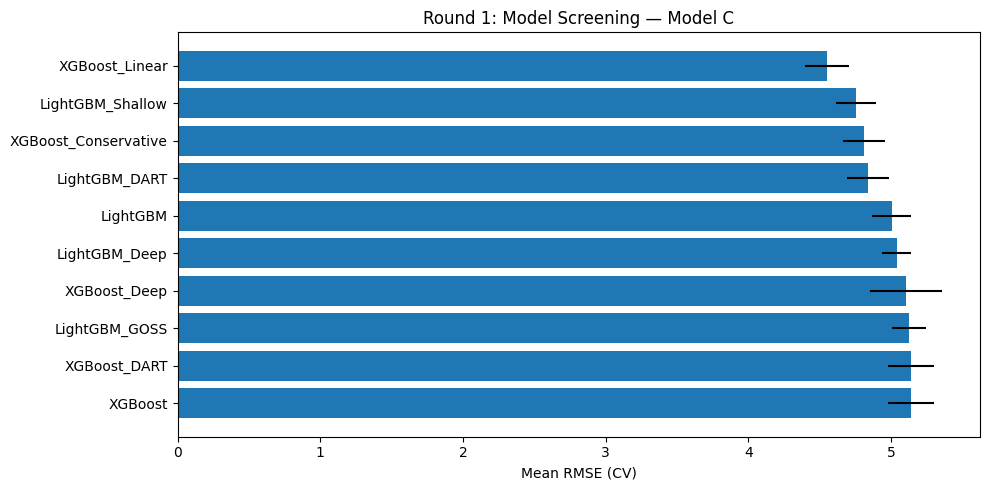

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(r1_results["model"], r1_results["mean_rmse"], xerr=r1_results["std_rmse"])
ax.set_xlabel("Mean RMSE (CV)")
ax.set_title("Round 1: Model Screening — Model C")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [11]:
top7_names = r1_results["model"].head(7).tolist()
print(f"Advancing to Round 2: {top7_names}")
eliminated = r1_results["model"].tail(3).tolist()
print(f"Eliminated: {eliminated}")

Advancing to Round 2: ['XGBoost_Linear', 'LightGBM_Shallow', 'XGBoost_Conservative', 'LightGBM_DART', 'LightGBM', 'LightGBM_Deep', 'XGBoost_Deep']
Eliminated: ['LightGBM_GOSS', 'XGBoost_DART', 'XGBoost']


## 4. Round 2 — Optuna HP Tuning (top 7, 10 trials each)

In [12]:
r2_results = []
for name in top7_names:
    print(f"Tuning {name}...")
    best_params, best_rmse = run_optuna_round(name, X, y, splitter, groups, n_trials=10)
    r2_results.append({"model": name, "best_rmse": best_rmse, "best_params": best_params})
    print(f"  Best RMSE: {best_rmse:.4f}")

r2_df = pd.DataFrame(r2_results).sort_values("best_rmse").reset_index(drop=True)
r2_df[["model", "best_rmse"]]

Tuning XGBoost_Linear...


  Best RMSE: 4.5247
Tuning LightGBM_Shallow...


  Best RMSE: 4.5816
Tuning XGBoost_Conservative...


  Best RMSE: 4.5721
Tuning LightGBM_DART...


  Best RMSE: 4.8366
Tuning LightGBM...


  Best RMSE: 4.5816
Tuning LightGBM_Deep...


  Best RMSE: 4.5816
Tuning XGBoost_Deep...


  Best RMSE: 4.5721


,model,best_rmse
0,XGBoost_Linear,4.524740
1,XGBoost_Conservative,4.572105
2,XGBoost_Deep,4.572105
3,LightGBM_Shallow,4.581578
4,LightGBM_Deep,4.581578
5,LightGBM,4.581578
6,LightGBM_DART,4.836639


In [13]:
top5_names = r2_df["model"].head(5).tolist()
r2_best_params = {row["model"]: row["best_params"] for _, row in r2_df.iterrows()}
print(f"Advancing to Round 3: {top5_names}")

Advancing to Round 3: ['XGBoost_Linear', 'XGBoost_Conservative', 'XGBoost_Deep', 'LightGBM_Shallow', 'LightGBM_Deep']


## 5. Round 3 — Final HP Tuning (top 5, 15 trials each)

In [14]:
r3_results = []
for name in top5_names:
    print(f"Fine-tuning {name}...")
    best_params, best_rmse = run_optuna_round(name, X, y, splitter, groups, n_trials=15)
    r3_results.append({"model": name, "best_rmse": best_rmse, "best_params": best_params})
    print(f"  Best RMSE: {best_rmse:.4f}")

r3_df = pd.DataFrame(r3_results).sort_values("best_rmse").reset_index(drop=True)
r3_best_params = {row["model"]: row["best_params"] for _, row in r3_df.iterrows()}
r3_df[["model", "best_rmse"]]

Fine-tuning XGBoost_Linear...


  Best RMSE: 4.5182
Fine-tuning XGBoost_Conservative...


  Best RMSE: 4.5721
Fine-tuning XGBoost_Deep...


  Best RMSE: 4.5721
Fine-tuning LightGBM_Shallow...


  Best RMSE: 4.5816
Fine-tuning LightGBM_Deep...


  Best RMSE: 4.5816


,model,best_rmse
0,XGBoost_Linear,4.518222
1,XGBoost_Conservative,4.572105
2,XGBoost_Deep,4.572105
3,LightGBM_Shallow,4.581578
4,LightGBM_Deep,4.581578


## 6. Test Set Evaluation

In [15]:
train_idx, test_idx = splitter.get_test_split(groups)
X_train_full, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train_full, y_test = y.iloc[train_idx], y.iloc[test_idx]
id_train, id_test = df[ID_COLS].iloc[train_idx], df[ID_COLS].iloc[test_idx]

print(f"Train: {X_train_full.shape}, Test: {X_test.shape}")
print(f"Test season(s): {sorted(df['season'].iloc[test_idx].unique())}")

Train: (2976, 15), Test: (479, 15)
Test season(s): [np.int64(2025)]


In [16]:
final_results = []
for name in top5_names:
    params = reconstruct_params(name, r3_best_params[name])
    model_cls = MODEL_CLASSES[name]
    model = model_cls(**params)
    model.fit(X_train_full, y_train_full)

    train_preds = model.predict(X_train_full)
    train_rmse = np.sqrt(mean_squared_error(y_train_full, train_preds))
    train_mae = mean_absolute_error(y_train_full, train_preds)

    test_preds = model.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    test_mae = mean_absolute_error(y_test, test_preds)

    val_rmse = r3_df.loc[r3_df["model"] == name, "best_rmse"].values[0]

    final_results.append({
        "model": name,
        "train_rmse": train_rmse, "train_mae": train_mae,
        "val_rmse": val_rmse,
        "test_rmse": test_rmse, "test_mae": test_mae,
        "overfit_gap": test_rmse - val_rmse,
    })

    print(f"{name}: train_rmse={train_rmse:.4f}, val_rmse={val_rmse:.4f}, "
          f"test_rmse={test_rmse:.4f}, gap={test_rmse - val_rmse:.4f}")

final_df = pd.DataFrame(final_results).sort_values("test_rmse").reset_index(drop=True)
final_df

XGBoost_Linear: train_rmse=4.4119, val_rmse=4.5182, test_rmse=4.3567, gap=-0.1615
XGBoost_Conservative: train_rmse=4.0265, val_rmse=4.5721, test_rmse=4.2543, gap=-0.3178


XGBoost_Deep: train_rmse=4.0265, val_rmse=4.5721, test_rmse=4.2543, gap=-0.3178
LightGBM_Shallow: train_rmse=4.0769, val_rmse=4.5816, test_rmse=4.2511, gap=-0.3305


LightGBM_Deep: train_rmse=4.0769, val_rmse=4.5816, test_rmse=4.2511, gap=-0.3305


,model,train_rmse,train_mae,val_rmse,test_rmse,test_mae,overfit_gap
0,LightGBM_Shallow,4.076949,3.202310,4.581578,4.251066,3.312300,-0.330512
1,LightGBM_Deep,4.076949,3.202310,4.581578,4.251066,3.312300,-0.330512
2,XGBoost_Deep,4.026515,3.171173,4.572105,4.254272,3.328674,-0.317833
3,XGBoost_Conservative,4.026515,3.171173,4.572105,4.254272,3.328674,-0.317833
4,XGBoost_Linear,4.411895,3.443784,4.518222,4.356720,3.394141,-0.161502


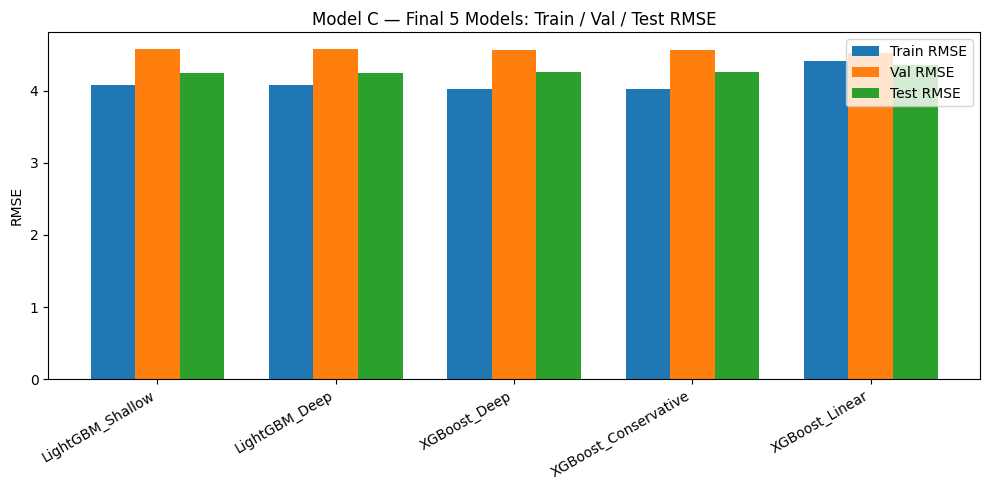

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(final_df))
w = 0.25
ax.bar(x - w, final_df["train_rmse"], w, label="Train RMSE")
ax.bar(x, final_df["val_rmse"], w, label="Val RMSE")
ax.bar(x + w, final_df["test_rmse"], w, label="Test RMSE")
ax.set_xticks(x)
ax.set_xticklabels(final_df["model"], rotation=30, ha="right")
ax.set_ylabel("RMSE")
ax.set_title("Model C — Final 5 Models: Train / Val / Test RMSE")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Save Artifacts

In [18]:
for name in top5_names:
    params = reconstruct_params(name, r3_best_params[name])
    model_cls = MODEL_CLASSES[name]
    model = model_cls(**params)
    model.fit(X_train_full, y_train_full)

    save_predictions(model, X_train_full, y_train_full, id_train, "C", name, "Training")
    save_predictions(model, X_test, y_test, id_test, "C", name, "Test")

    # OOF validation predictions (for Model D stacking)
    oof_preds = np.full(len(X), np.nan)
    for tr_idx, va_idx in splitter.split(groups):
        import sklearn.base
        fold_model = sklearn.base.clone(model)
        fold_model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        oof_preds[va_idx] = fold_model.predict(X.iloc[va_idx])

    val_mask = ~np.isnan(oof_preds)
    val_out = df[ID_COLS].loc[val_mask].copy()
    val_out["y_true"] = y.loc[val_mask].values
    val_out["y_pred"] = oof_preds[val_mask]
    fname = f"model_C_{name}_Validation.parquet"
    uri = save_training_parquet(val_out, fname, TRAINING_DIR)
    print(f"  Saved {fname} -> {uri}")

    save_model_pkl(model, "C", name)

print("\nDone! All Model C artifacts saved.")

  Saved model_C_XGBoost_Linear_Training.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_C_XGBoost_Linear_Training.parquet
  Saved model_C_XGBoost_Linear_Test.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_C_XGBoost_Linear_Test.parquet


  Saved model_C_XGBoost_Linear_Validation.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_C_XGBoost_Linear_Validation.parquet
  Saved Model_C_XGBoost_Linear.pkl -> gs://f1-predictor-artifacts-jowin/data/raw/model/Model_C_XGBoost_Linear.pkl


  Saved model_C_XGBoost_Conservative_Training.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_C_XGBoost_Conservative_Training.parquet
  Saved model_C_XGBoost_Conservative_Test.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_C_XGBoost_Conservative_Test.parquet


  Saved model_C_XGBoost_Conservative_Validation.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_C_XGBoost_Conservative_Validation.parquet
  Saved Model_C_XGBoost_Conservative.pkl -> gs://f1-predictor-artifacts-jowin/data/raw/model/Model_C_XGBoost_Conservative.pkl


  Saved model_C_XGBoost_Deep_Training.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_C_XGBoost_Deep_Training.parquet
  Saved model_C_XGBoost_Deep_Test.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_C_XGBoost_Deep_Test.parquet


  Saved model_C_XGBoost_Deep_Validation.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_C_XGBoost_Deep_Validation.parquet
  Saved Model_C_XGBoost_Deep.pkl -> gs://f1-predictor-artifacts-jowin/data/raw/model/Model_C_XGBoost_Deep.pkl


  Saved model_C_LightGBM_Shallow_Training.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_C_LightGBM_Shallow_Training.parquet
  Saved model_C_LightGBM_Shallow_Test.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_C_LightGBM_Shallow_Test.parquet


  Saved model_C_LightGBM_Shallow_Validation.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_C_LightGBM_Shallow_Validation.parquet
  Saved Model_C_LightGBM_Shallow.pkl -> gs://f1-predictor-artifacts-jowin/data/raw/model/Model_C_LightGBM_Shallow.pkl


  Saved model_C_LightGBM_Deep_Training.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_C_LightGBM_Deep_Training.parquet
  Saved model_C_LightGBM_Deep_Test.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_C_LightGBM_Deep_Test.parquet


  Saved model_C_LightGBM_Deep_Validation.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_C_LightGBM_Deep_Validation.parquet
  Saved Model_C_LightGBM_Deep.pkl -> gs://f1-predictor-artifacts-jowin/data/raw/model/Model_C_LightGBM_Deep.pkl

Done! All Model C artifacts saved.


## Summary

In [19]:
print("=" * 60)
print("MODEL C TRAINING COMPLETE")
print("=" * 60)
print(f"\nFinal 5 models (sorted by test RMSE):")
for _, row in final_df.iterrows():
    print(f"  {row['model']:20s}  test_rmse={row['test_rmse']:.4f}  gap={row['overfit_gap']:.4f}")
print(f"\nArtifacts saved to:")
print(f"  Predictions: {TRAINING_DIR}")
print(f"  Models: {MODEL_DIR}")

MODEL C TRAINING COMPLETE

Final 5 models (sorted by test RMSE):
  LightGBM_Shallow      test_rmse=4.2511  gap=-0.3305
  LightGBM_Deep         test_rmse=4.2511  gap=-0.3305
  XGBoost_Deep          test_rmse=4.2543  gap=-0.3178
  XGBoost_Conservative  test_rmse=4.2543  gap=-0.3178
  XGBoost_Linear        test_rmse=4.3567  gap=-0.1615

Artifacts saved to:
  Predictions: data/training
  Models: data/raw/model
